手写结果: w = 2.93, b = 2.31
理论值:   w = 3.00, b = 2.00
最终MSE = 3.23


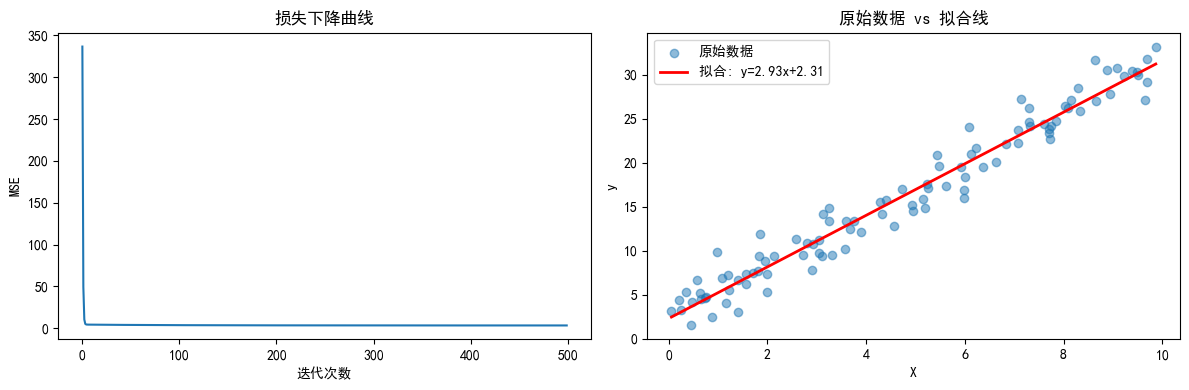

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 1. 造数据：y = 3x + 2 + 噪声 ====================
np.random.seed(42)
X = np.random.rand(100) * 10          # 100个样本，0~10之间
y = 3 * X + 2 + np.random.randn(100) * 2  # 真实关系 + 噪声

# ==================== 2. 初始化 ====================
w = 0.0    # 权重，从0开始
b = 0.0    # 偏置，从0开始
alpha = 0.01   # 学习率
epochs = 500   # 迭代次数
m = len(X)

loss_history = []

# ==================== 3. 梯度下降循环 ====================
for epoch in range(epochs):
    # 前向传播：算预测值
    y_pred = w * X + b
    
    # 计算均方误差
    loss = np.mean((y_pred - y) ** 2)
    loss_history.append(loss)
    
    # 计算梯度（偏导数）
    dw = (2 / m) * np.sum((y_pred - y) * X)   # J对w的偏导
    db = (2 / m) * np.sum(y_pred - y)         # J对b的偏导
    
    # 更新参数：沿梯度反方向走一步
    w -= alpha * dw
    b -= alpha * db

print(f"手写结果: w = {w:.2f}, b = {b:.2f}")
print(f"理论值:   w = 3.00, b = 2.00")
print(f"最终MSE = {loss_history[-1]:.2f}")

# ==================== 4. 画图 ====================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel("迭代次数")
plt.ylabel("MSE")
plt.title("损失下降曲线")

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.5, label="原始数据")
plt.plot([X.min(), X.max()], [w*X.min()+b, w*X.max()+b], 'r', lw=2, label=f"拟合: y={w:.2f}x+{b:.2f}")
plt.xlabel("X")
plt.ylabel("y")
plt.title("原始数据 vs 拟合线")
plt.legend()

plt.tight_layout()
plt.show()